# Installations

In [2]:
%pip install fasttext fasttext-wheel
%pip install fasttext-numpy2
%pip install datasets
%pip install sentence-transformers
%pip install umap-learn
%pip install hdbscan

# Imports

In [3]:
import fasttext
import urllib.request
import os
#--------------------------------
from umap import UMAP
from hdbscan import HDBSCAN
#--------------------------------
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
#--------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
#--------------------------------
import warnings
warnings.filterwarnings("ignore")

# Loading Dataset

In [4]:
dataset = load_dataset("BAAI/IndustryInstruction_Finance-Economics")["train"]

------------------

# language detection and filtering

In [5]:
# Downloading the pre-trained language detection model
model_url:str = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz"
model_path:str = "lid.176.ftz"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

lang_model = fasttext.load_model(model_path)

In [6]:
en_texts: list[str] = []
min_char_length:int = 300 # Only take detailed answers

for row in tqdm(dataset["conversations"]):
    # 1. Extract the GPT response
    text = next((turn["value"] for turn in row if turn["from"] == "gpt"), "")

    # 2. Stratify by Quality (Length)
    if len(text) > min_char_length:

        # 3. Detect Language (must be '__label__en')
        # We replace newlines because fastText works best on single-line inputs
        prediction = lang_model.predict(text.replace("\n", " "), k=1)
        language = prediction[0][0].replace("__label__", "")
        confidence = prediction[1][0]

        if language == "en" and confidence > 0.8:
            en_texts.append(text)

print(f"Total rows processed: {len(dataset)}")
print(f"Final English High-Quality count: {len(en_texts)}")

100%|██████████| 122090/122090 [00:36<00:00, 3353.85it/s]

Total rows processed: 122090
Final English High-Quality count: 74477


# Embedding the text

In [7]:
# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(en_texts, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2328 [00:00<?, ?it/s]

# Reducing dimensionality

In [8]:
# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
                )

reduced_embeddings = umap_model.fit_transform(embeddings)

# Clustering the text

In [9]:
# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

172

In [10]:
# Print first three documents in cluster 0
cluster:int = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(en_texts[index][:300] + "... \n ------------------------------ \n")

To enhance operational efficiency, China Tower adopted a flat organizational structure to reduce the number of management layers and concentrate the focus at the city level. The company's headquarters is designed with only nine departments, no sub-departments within the departments, and a total staf... 
 ------------------------------ 

The primary goals of the reform in the mechanism for deciding on SOE wages in Sichuan Province are to establish a more flexible and efficient operation mechanism for state-owned enterprises, driving them to improve development quality and efficiency. This involves reforming the way annual wage total... 
 ------------------------------ 

The Shenzhen Stock Exchange has played a significant role in supporting the restructuring and reform of state-owned enterprises by serving as a "catalyst" and "accelerator" for the promotion of state-owned enterprises reform. The Exchange has pushed state-owned holding companies to carry out strateg... 
 ----------------

# Visualizing

In [11]:
# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])

df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

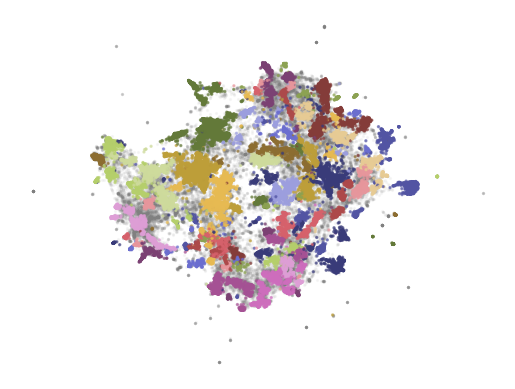

In [12]:
# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
plt.savefig("matplotlib.png", dpi=300)

# trying different parameter combinations

## the Fine-Grained approach

Use this if you think your data has many small, specific sub-topics.

In [13]:
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    cluster_selection_method='leaf'
).fit(reduced_embeddings)

clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])

df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

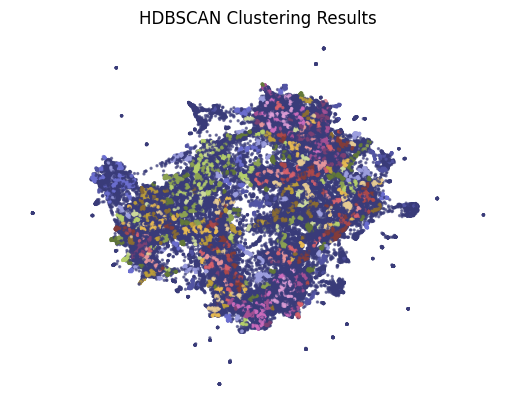

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create separate dataframes for outliers and clustered points
# Assuming your main dataframe is named 'df' with columns ['x', 'y', 'cluster']
outliers_df = df[df.cluster == -1]
clusters_df = df[df.cluster != -1]

# 2. Plot outliers (represented by -1)
# Use a very low alpha (0.05) to keep them visible but unobtrusive
plt.scatter(
    outliers_df.x,
    outliers_df.y,
    alpha=0.05,
    s=2,
    c="grey",
    label="Noise"
)

# 3. Plot the clusters
# Use a categorical colormap like 'tab20b' or 'hsv' for high contrast
plt.scatter(
    clusters_df.x,
    clusters_df.y,
    c=clusters_df.cluster.astype(int),
    alpha=0.6,
    s=2,
    cmap='tab20b'
)

# 4. Cleanup and Save
plt.axis('off')
plt.title("HDBSCAN Clustering Results", fontsize=12)
plt.savefig("hdbscan_visualization.png", dpi=300, bbox_inches='tight')

## The "Conservative/High-Quality" Approach

Use this if you only care about very distinct, dense groups and want to ignore the "messy" data in between.

In [15]:
hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    min_samples=100,
    cluster_selection_method='eom'
).fit(reduced_embeddings)

clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])

df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

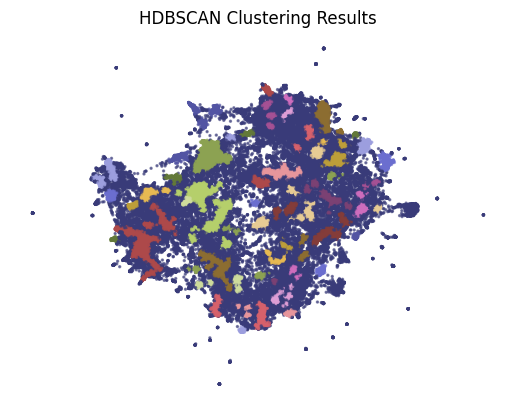

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create separate dataframes for outliers and clustered points
# Assuming your main dataframe is named 'df' with columns ['x', 'y', 'cluster']
outliers_df = df[df.cluster == -1]
clusters_df = df[df.cluster != -1]

# 2. Plot outliers (represented by -1)
# Use a very low alpha (0.05) to keep them visible but unobtrusive
plt.scatter(
    outliers_df.x,
    outliers_df.y,
    alpha=0.05,
    s=2,
    c="grey",
    label="Noise"
)

# 3. Plot the clusters
# Use a categorical colormap like 'tab20b' or 'hsv' for high contrast
plt.scatter(
    clusters_df.x,
    clusters_df.y,
    c=clusters_df.cluster.astype(int),
    alpha=0.6,
    s=2,
    cmap='tab20b'
)

# 4. Cleanup and Save
plt.axis('off')
plt.title("HDBSCAN Clustering Results", fontsize=12)
plt.savefig("hdbscan_visualization.png", dpi=300, bbox_inches='tight')